Train: (56000, 50), Test: (14000, 50), Churn rate: 41.74%

[Feature Selection]
Selected 25/50 features

[Training Stacking Model]

[Threshold Optimization]
Best threshold: 0.39 | F1: 0.6020 | Recall: 0.8978


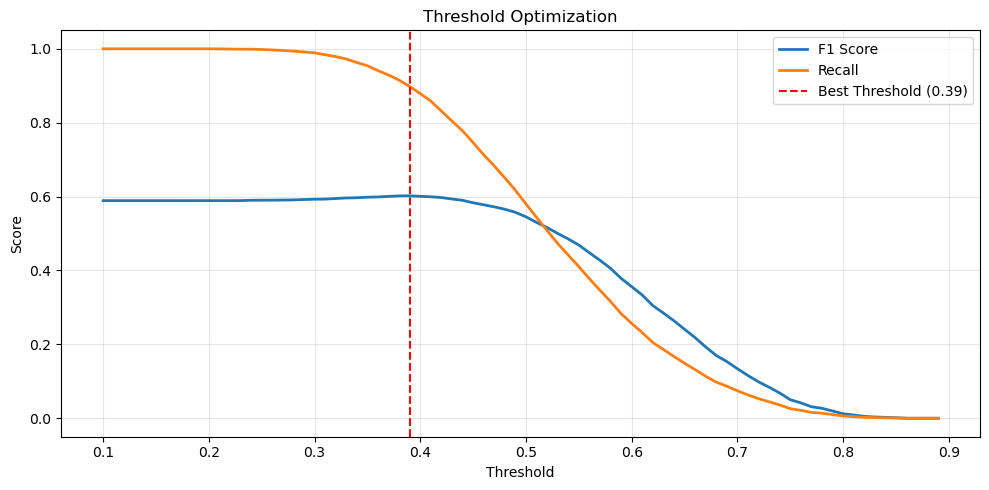


[Evaluation]
ROC-AUC: 0.6303

              precision    recall  f1-score   support

           0       0.75      0.22      0.34      8156
           1       0.45      0.90      0.60      5844

    accuracy                           0.50     14000
   macro avg       0.60      0.56      0.47     14000
weighted avg       0.63      0.50      0.45     14000


Confusion Matrix: TN=1816, FP=6340, FN=597, TP=5247


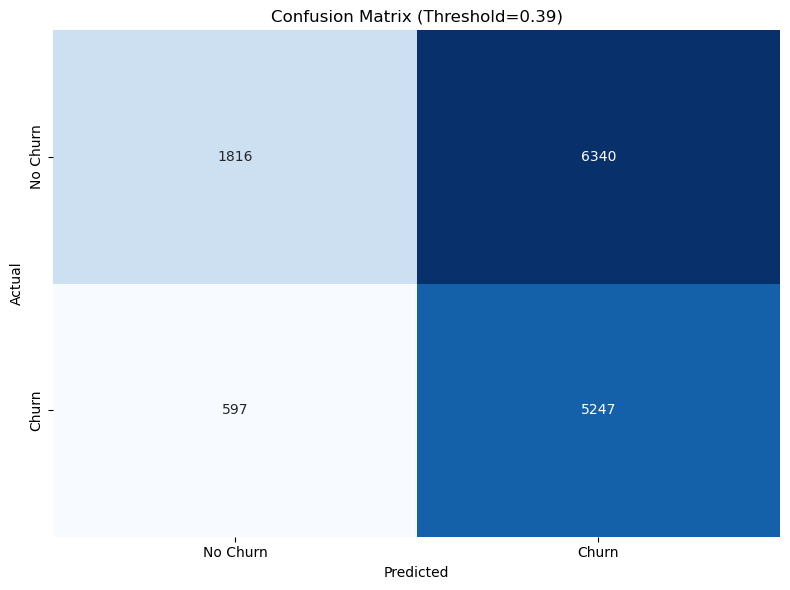


Top 10 Features:
              feature  importance
    ChargesPerProduct        2152
SatisfactionIndex_Raw        2081
    SatisfactionScore        1681
   Products_Per_Month        1541
        RiskScore_Raw        1534
                  Age        1523
  EngagementScore_Raw        1512
           Age_Tenure        1486
     Usage_Per_Dollar        1469
        Recency_Ratio        1462


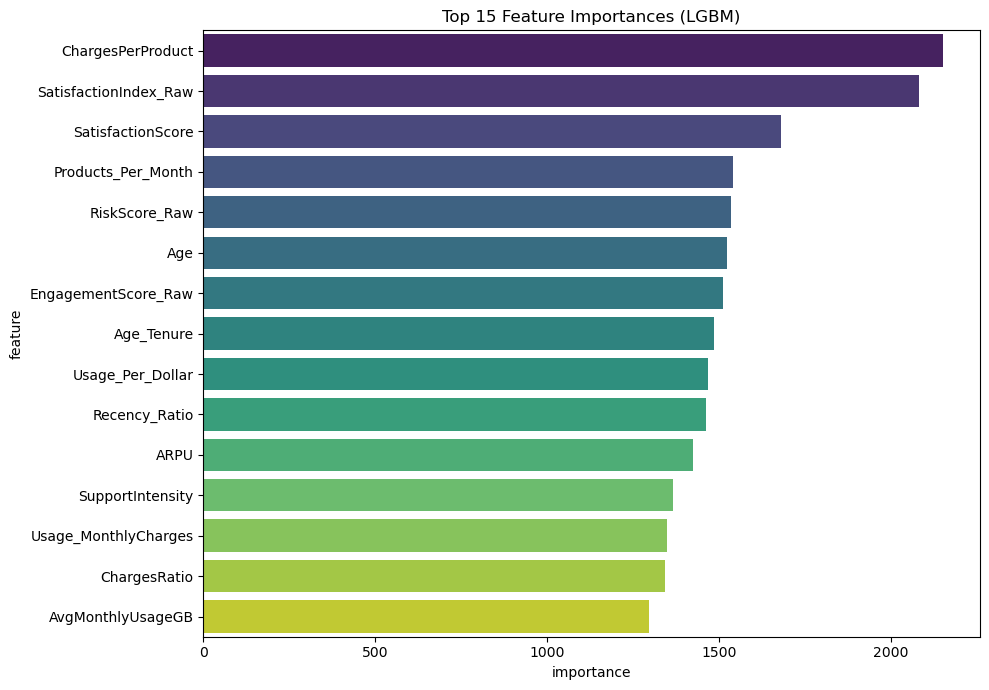


✓ Artifacts saved to ../models and ../data/results


Exception ignored in: <function ResourceTracker.__del__ at 0x10773dbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1050a5bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1029f9bc0>
Traceback (most recent call last

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# NOTEBOOK 11: LightGBM Model Tuning & Threshold Optimization for Maximum Recall
# ═══════════════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, f1_score, recall_score
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.feature_selection import SelectFromModel
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Enable inline plotting for notebooks
%matplotlib inline

# ═══════════════════════════════════════════════════════════════════════════════
# Config
# ═══════════════════════════════════════════════════════════════════════════════
RANDOM_STATE = 42
N_JOBS = -1
DATA_DIR = Path('../data')
RESULTS_DIR = DATA_DIR / 'results'
MODELS_DIR = Path('../models')

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# ═══════════════════════════════════════════════════════════════════════════════
# Step 1: Load data
# ═══════════════════════════════════════════════════════════════════════════════
train_df = pd.read_csv(DATA_DIR / 'processed/train_data_final.csv')
test_df = pd.read_csv(DATA_DIR / 'processed/test_data_final.csv')

X_train = train_df.drop('Churn', axis=1)
y_train = train_df['Churn']
X_test = test_df.drop('Churn', axis=1)
y_test = test_df['Churn']

print(f"Train: {X_train.shape}, Test: {X_test.shape}, Churn rate: {y_train.mean():.2%}")

# ═══════════════════════════════════════════════════════════════════════════════
# Step 2: Feature Selection
# ═══════════════════════════════════════════════════════════════════════════════
print("\n[Feature Selection]")

fs_model = LGBMClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    num_leaves=31,
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS,
    class_weight='balanced',
    verbose=-1
)

fs_model.fit(X_train, y_train)
selector = SelectFromModel(fs_model, threshold='median', prefit=True)

X_train_sel = pd.DataFrame(
    selector.transform(X_train),
    columns=X_train.columns[selector.get_support()],
    index=X_train.index
)
X_test_sel = pd.DataFrame(
    selector.transform(X_test),
    columns=X_test.columns[selector.get_support()],
    index=X_test.index
)
selected_features = X_train_sel.columns.tolist()

print(f"Selected {len(selected_features)}/{X_train.shape[1]} features")

# ═══════════════════════════════════════════════════════════════════════════════
# Step 3: Define base models
# ═══════════════════════════════════════════════════════════════════════════════
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

base_models = {
    'lgbm': LGBMClassifier(
        n_estimators=900,
        max_depth=6,
        learning_rate=0.03,
        num_leaves=40,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS,
        verbose=-1
    ),
    'xgb': XGBClassifier(
        n_estimators=900,
        max_depth=6,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS,
        verbosity=0
    ),
    'catboost': CatBoostClassifier(
        iterations=900,
        depth=6,
        learning_rate=0.03,
        l2_leaf_reg=3,
        subsample=0.8,
        bootstrap_type='Bernoulli',
        auto_class_weights='Balanced',
        random_state=RANDOM_STATE,
        verbose=0
    )
}

# ═══════════════════════════════════════════════════════════════════════════════
# Step 4: Stacking Classifier
# ═══════════════════════════════════════════════════════════════════════════════
stack = StackingClassifier(
    estimators=list(base_models.items()),
    final_estimator=LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=N_JOBS,
    passthrough=True
)

# ═══════════════════════════════════════════════════════════════════════════════
# Step 5: Train
# ═══════════════════════════════════════════════════════════════════════════════
print("\n[Training Stacking Model]")
stack.fit(X_train_sel, y_train)

# ═══════════════════════════════════════════════════════════════════════════════
# Step 6: Threshold Optimization (F1 + Recall)
# ═══════════════════════════════════════════════════════════════════════════════
print("\n[Threshold Optimization]")
y_pred_proba = stack.predict_proba(X_test_sel)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.01)
metrics = []

for t in thresholds:
    preds = (y_pred_proba >= t).astype(int)
    metrics.append({
        'threshold': t,
        'f1': f1_score(y_test, preds),
        'recall': recall_score(y_test, preds)
    })

metrics_df = pd.DataFrame(metrics)
best_f1_idx = metrics_df['f1'].idxmax()
best_t = metrics_df.loc[best_f1_idx, 'threshold']
best_f1 = metrics_df.loc[best_f1_idx, 'f1']

print(f"Best threshold: {best_t:.2f} | F1: {best_f1:.4f} | Recall: {metrics_df.loc[best_f1_idx, 'recall']:.4f}")

# Plot threshold vs metrics
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(metrics_df['threshold'], metrics_df['f1'], label='F1 Score', linewidth=2)
ax.plot(metrics_df['threshold'], metrics_df['recall'], label='Recall', linewidth=2)
ax.axvline(best_t, color='red', linestyle='--', label=f'Best Threshold ({best_t:.2f})')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold Optimization')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / '11_threshold_optimization.png', dpi=300, bbox_inches='tight')
plt.show()

y_pred = (y_pred_proba >= best_t).astype(int)

# ═══════════════════════════════════════════════════════════════════════════════
# Step 7: Evaluation
# ═══════════════════════════════════════════════════════════════════════════════
print("\n[Evaluation]")
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC: {auc_score:.4f}")
print("\n" + classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}")

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
ax.set_title(f'Confusion Matrix (Threshold={best_t:.2f})')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig(RESULTS_DIR / '11_confusion_matrix_stacking.png', dpi=300, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# Step 8: Feature Importance
# ═══════════════════════════════════════════════════════════════════════════════
lgbm_fitted = stack.named_estimators_['lgbm']

feat_imp_df = pd.DataFrame({
    'feature': selected_features,
    'importance': lgbm_fitted.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nTop 10 Features:\n{feat_imp_df.head(10).to_string(index=False)}")

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=feat_imp_df.head(15), x='importance', y='feature', ax=ax, hue='feature', palette='viridis', legend=False)
ax.set_title('Top 15 Feature Importances (LGBM)')
plt.tight_layout()
plt.savefig(RESULTS_DIR / '11_feature_importance_stacking.png', dpi=300, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# Step 9: Save artifacts
# ═══════════════════════════════════════════════════════════════════════════════
artifacts = {
    'model': stack,
    'selector': selector,
    'selected_features': selected_features,
    'best_threshold': best_t,
    'metrics': {
        'auc': auc_score,
        'f1': best_f1,
        'recall': metrics_df.loc[best_f1_idx, 'recall'],
        'confusion_matrix': cm.tolist()
    }
}

joblib.dump(artifacts, MODELS_DIR / 'stacking_model_full.pkl')
feat_imp_df.to_csv(RESULTS_DIR / 'feature_importance_stacking.csv', index=False)
metrics_df.to_csv(RESULTS_DIR / 'threshold_metrics.csv', index=False)

print(f"\n✓ Artifacts saved to {MODELS_DIR} and {RESULTS_DIR}")
